# CMIP6 historical ensemble: net TOA radiation

Load annual global-mean CMIP6 historical radiation fluxes from the Nicholls et al. archive and calculate

$$N = rsdt - rsut - rlut,$$

where positive $N$ is downward (energy accumulation by the climate system). Under CMIP conventions, `rsdt` is incoming shortwave radiation and `rsut` and `rlut` are outgoing shortwave and longwave radiation.

The archive files are annual, area-weighted regional means in MAGICC text format. This notebook reads the `WORLD` column, so no additional spatial weighting is needed. It uses the unmodified `netcdf-scm_*.MAG` product by default and can be switched to the archive's `DEDRIFTED_` product in the configuration cell. It deliberately does not use `NORMED_` files.

Selection is conservative: a member must have all three variables, the requested first year, and every year through 2014. Split file segments are joined, and the newest archive version wins wherever versions overlap.

In [1]:
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

pd.set_option("display.max_colwidth", 120)

CMIP_ROOT = Path(
    "/glade/derecho/scratch/vcooper/p2c2/historical/"
    "nicholls2021_cmip6/average-year-mid-year/CMIP6/CMIP"
)

# Easy product switch: choose "raw" or "dedrifted".
# DATA_PRODUCT = "raw"
DATA_PRODUCT = "dedrifted"
PRODUCT_PREFIX = {
    "raw": "netcdf-scm_",
    "dedrifted": "DEDRIFTED_netcdf-scm_",
}

START_YEAR = 1850
END_YEAR = 2014  # Standard end of the CMIP6 historical experiment.
REQUIRE_EXACT_START = True
VARIABLES = ("rsdt", "rsut", "rlut")

if DATA_PRODUCT not in PRODUCT_PREFIX:
    raise ValueError(f"DATA_PRODUCT must be one of {tuple(PRODUCT_PREFIX)}")
if not CMIP_ROOT.is_dir():
    raise FileNotFoundError(CMIP_ROOT)

print(f"Product: {DATA_PRODUCT!r}")
print(f"Required coverage: {START_YEAR}-{END_YEAR}")
print(f"Require first available year == {START_YEAR}: {REQUIRE_EXACT_START}")

Product: 'dedrifted'
Required coverage: 1850-2014
Require first available year == 1850: True


## Product choice

Use `DATA_PRODUCT = "raw"` to study the absolute simulated TOA imbalance. Use `DATA_PRODUCT = "dedrifted"` to use the archive's externally generated drift-adjusted fluxes. The latter can be valuable for sensitivity checks, but it is not interchangeable with the raw absolute imbalance: the inferred spread can change because drift correction changes each model's flux history. The notebook records the selected product and exact source files in the provenance table.

In [2]:
def read_magicc_world(path):
    """Read the annual WORLD column from a Nicholls archive MAGICC file."""
    path = Path(path)
    with path.open(errors="replace") as stream:
        for row_number, line in enumerate(stream):
            if line.split()[:1] == ["YEARS"]:
                header_row = row_number
                break
        else:
            raise ValueError(f"No YEARS header found in {path}")

    frame = pd.read_csv(
        path,
        sep=r"\s+",
        skiprows=header_row,
        usecols=["YEARS", "WORLD"],
    )
    series = pd.Series(
        frame["WORLD"].to_numpy(dtype=float),
        index=frame["YEARS"].to_numpy(dtype=int),
        name=path.parts[-4],
    ).sort_index()
    series.index.name = "year"
    if series.index.has_duplicates:
        raise ValueError(f"Duplicate years within {path}")
    return series


def discover_files(root, prefix):
    """Map (institution, source_id, variant_label) to files for each variable."""
    grouped = defaultdict(lambda: defaultdict(list))
    for variable in VARIABLES:
        pattern = (
            f"*/*/historical/*/Amon/{variable}/*/*/"
            f"{prefix}{variable}_*.MAG"
        )
        for path in root.glob(pattern):
            relative = path.relative_to(root).parts
            if len(relative) != 9:
                continue
            (
                institution, source_id, experiment_id, variant_label, table_id,
                found_variable, grid_label, version, filename,
            ) = relative
            if experiment_id != "historical" or found_variable != variable:
                continue
            grouped[(institution, source_id, variant_label)][variable].append(path)
    return grouped


def merge_product_segments(paths):
    """Join split time segments; newest version wins for overlapping years."""
    rows = []
    for path in paths:
        series = read_magicc_world(path)
        rows.append(
            pd.DataFrame(
                {
                    "year": series.index,
                    "value": series.to_numpy(),
                    "version": path.parent.name,
                    # Prefer the native grid only when version labels tie.
                    "native_grid": int(path.parent.parent.name == "gn"),
                    "path": str(path),
                }
            )
        )

    combined = pd.concat(rows, ignore_index=True)
    combined = combined.sort_values(
        ["year", "version", "native_grid", "path"]
    )
    chosen = combined.drop_duplicates("year", keep="last").sort_values("year")
    series = chosen.set_index("year")["value"]
    contributes = chosen["year"].between(START_YEAR, END_YEAR)
    used_paths = tuple(sorted(chosen.loc[contributes, "path"].unique()))
    return series, used_paths

In [3]:
# Raw files define the archive's candidate-member universe. This makes missing
# dedrifted products visible in the rejection audit after switching products.
raw_files = discover_files(CMIP_ROOT, PRODUCT_PREFIX["raw"])
selected_files = discover_files(CMIP_ROOT, PRODUCT_PREFIX[DATA_PRODUCT])

discovery_summary = pd.DataFrame(
    {
        "raw archive": [
            sum(len(paths) for by_var in raw_files.values() for paths in by_var.values()),
            len(raw_files),
            sum(set(by_var) == set(VARIABLES) for by_var in raw_files.values()),
        ],
        DATA_PRODUCT: [
            sum(len(paths) for by_var in selected_files.values() for paths in by_var.values()),
            len(selected_files),
            sum(set(by_var) == set(VARIABLES) for by_var in selected_files.values()),
        ],
    },
    index=["files", "member identities", "complete variable triplets"],
)
discovery_summary

,raw archive,dedrifted
files,1649,745
member identities,519,259
complete variable triplets,513,241


In [4]:
def build_net_toa_dataset(raw_universe, product_files):
    expected_years = pd.Index(range(START_YEAR, END_YEAR + 1), name="year")
    member_frames = []
    included_rows = []
    rejected_rows = []

    for institution, source_id, variant_label in sorted(raw_universe):
        key = (institution, source_id, variant_label)
        files_by_variable = product_files.get(key, {})
        missing_variables = sorted(set(VARIABLES) - set(files_by_variable))
        member = "/".join(key)

        if missing_variables:
            rejected_rows.append(
                {
                    "member": member,
                    "institution": institution,
                    "source_id": source_id,
                    "variant_label": variant_label,
                    "primary_reason": f"missing {DATA_PRODUCT} variable(s)",
                    "details": ", ".join(missing_variables),
                }
            )
            continue

        series_by_variable = {}
        paths_by_variable = {}
        first_years = {}
        reasons = []

        for variable in VARIABLES:
            series, used_paths = merge_product_segments(files_by_variable[variable])
            finite_series = series.dropna()
            if finite_series.empty:
                reasons.append(f"{variable}: no finite values")
                continue

            first_years[variable] = int(finite_series.index.min())
            if REQUIRE_EXACT_START and first_years[variable] != START_YEAR:
                reasons.append(f"{variable}: first year {first_years[variable]}")

            missing_years = expected_years.difference(finite_series.index)
            if len(missing_years):
                reasons.append(
                    f"{variable}: missing {len(missing_years)} required year(s)"
                )

            series_by_variable[variable] = series
            paths_by_variable[variable] = used_paths

        if reasons:
            primary_reason = (
                f"first year is not {START_YEAR}"
                if any("first year" in reason for reason in reasons)
                else "incomplete required coverage"
            )
            rejected_rows.append(
                {
                    "member": member,
                    "institution": institution,
                    "source_id": source_id,
                    "variant_label": variant_label,
                    "primary_reason": primary_reason,
                    "details": "; ".join(reasons),
                }
            )
            continue

        frame = pd.concat(
            {
                variable: series_by_variable[variable].reindex(expected_years)
                for variable in VARIABLES
            },
            axis=1,
        )
        frame["net_toa"] = frame["rsdt"] - frame["rsut"] - frame["rlut"]
        member_frames.append((member, frame))

        included_rows.append(
            {
                "member": member,
                "institution": institution,
                "source_id": source_id,
                "variant_label": variant_label,
                "product": DATA_PRODUCT,
                "first_available_year": min(first_years.values()),
                "last_common_available_year": min(
                    int(series_by_variable[v].dropna().index.max()) for v in VARIABLES
                ),
                **{
                    f"{variable}_files": " | ".join(paths_by_variable[variable])
                    for variable in VARIABLES
                },
            }
        )

    if not member_frames:
        raise RuntimeError("No members passed the selection rules")

    member_ids = np.array([member for member, _ in member_frames], dtype=str)
    years = expected_years.to_numpy(dtype=int)
    data_variables = {
        variable: (
            ("member", "year"),
            np.stack([frame[variable].to_numpy() for _, frame in member_frames]),
        )
        for variable in (*VARIABLES, "net_toa")
    }
    dataset = xr.Dataset(
        data_variables,
        coords={"member": member_ids, "year": years},
    )

    provenance = pd.DataFrame(included_rows).set_index("member").loc[member_ids]
    rejected = pd.DataFrame(rejected_rows)
    for coordinate in ("institution", "source_id", "variant_label"):
        dataset = dataset.assign_coords(
            {coordinate: ("member", provenance[coordinate].to_numpy(dtype=str))}
        )

    for variable in (*VARIABLES, "net_toa"):
        dataset[variable].attrs["units"] = "W m-2"
    dataset["net_toa"].attrs.update(
        {
            "long_name": "Net top-of-atmosphere downward radiative flux",
            "formula": "rsdt - rsut - rlut",
            "positive": "down",
        }
    )
    dataset.attrs.update(
        {
            "source_archive": str(CMIP_ROOT),
            "data_product": DATA_PRODUCT,
            "selection": (
                f"all rsdt, rsut, and rlut years {START_YEAR}-{END_YEAR}; "
                f"exact_start={REQUIRE_EXACT_START}"
            ),
        }
    )
    return dataset, provenance, rejected


In [5]:
net_toa_ds, provenance, rejected = build_net_toa_dataset(raw_files, selected_files)

selection_summary = pd.Series(
    {
        "candidate member identities": len(raw_files),
        "included members": net_toa_ds.sizes["member"],
        "included institution/source_id pairs": provenance.reset_index()[
            ["institution", "source_id"]
        ].drop_duplicates().shape[0],
        "included distinct source_id values": provenance["source_id"].nunique(),
        "excluded member identities": len(rejected),
    },
    name="count",
)
display(selection_summary.to_frame())
display(rejected["primary_reason"].value_counts().rename("count").to_frame())
display(rejected.head(15))

,count
candidate member identities,519
included members,241
included institution/source_id pairs,30
included distinct source_id values,30
excluded member identities,278


,count
primary_reason,
missing dedrifted variable(s),278


,member,institution,source_id,variant_label,primary_reason,details
0,AS-RCEC/TaiESM1/r1i1p1f1,AS-RCEC,TaiESM1,r1i1p1f1,missing dedrifted variable(s),"rlut, rsdt, rsut"
1,BCC/BCC-CSM2-MR/r1i1p1f1,BCC,BCC-CSM2-MR,r1i1p1f1,missing dedrifted variable(s),"rlut, rsdt, rsut"
2,BCC/BCC-CSM2-MR/r2i1p1f1,BCC,BCC-CSM2-MR,r2i1p1f1,missing dedrifted variable(s),"rlut, rsdt, rsut"
3,BCC/BCC-CSM2-MR/r3i1p1f1,BCC,BCC-CSM2-MR,r3i1p1f1,missing dedrifted variable(s),"rlut, rsdt, rsut"
4,CAMS/CAMS-CSM1-0/r1i1p1f1,CAMS,CAMS-CSM1-0,r1i1p1f1,missing dedrifted variable(s),"rlut, rsdt, rsut"
5,CAMS/CAMS-CSM1-0/r1i1p1f2,CAMS,CAMS-CSM1-0,r1i1p1f2,missing dedrifted variable(s),"rlut, rsdt, rsut"
6,CAMS/CAMS-CSM1-0/r2i1p1f1,CAMS,CAMS-CSM1-0,r2i1p1f1,missing dedrifted variable(s),"rlut, rsdt, rsut"
7,CAS/FGOALS-f3-L/r1i1p1f1,CAS,FGOALS-f3-L,r1i1p1f1,missing dedrifted variable(s),"rlut, rsdt, rsut"
8,CAS/FGOALS-f3-L/r2i1p1f1,CAS,FGOALS-f3-L,r2i1p1f1,missing dedrifted variable(s),"rlut, rsdt, rsut"
9,CAS/FGOALS-f3-L/r3i1p1f1,CAS,FGOALS-f3-L,r3i1p1f1,missing dedrifted variable(s),"rlut, rsdt, rsut"


In [6]:
# Fail loudly if coverage, finiteness, or the radiation identity is violated.
expected_years = np.arange(START_YEAR, END_YEAR + 1)
np.testing.assert_array_equal(net_toa_ds["year"].values, expected_years)
assert np.isfinite(net_toa_ds.to_array().values).all()
identity_error = abs(
    net_toa_ds["net_toa"]
    - (net_toa_ds["rsdt"] - net_toa_ds["rsut"] - net_toa_ds["rlut"])
).max().item()
assert identity_error < 1e-10

validation = pd.DataFrame(
    {
        "minimum": [net_toa_ds[v].min().item() for v in (*VARIABLES, "net_toa")],
        "maximum": [net_toa_ds[v].max().item() for v in (*VARIABLES, "net_toa")],
        "missing values": [
            int(net_toa_ds[v].isnull().sum()) for v in (*VARIABLES, "net_toa")
        ],
    },
    index=[*VARIABLES, "net_toa"],
)
print(f"Maximum formula identity error: {identity_error:.3g} W m-2")
validation

Maximum formula identity error: 0 W m-2


,minimum,maximum,missing values
rsdt,337.2660,341.8940,0
rsut,95.2104,113.0270,0
rlut,226.8320,246.0710,0
net_toa,-3.0740,3.6841,0


In [7]:
members_by_model = (
    provenance.reset_index()
    .groupby(["institution", "source_id"], as_index=False)
    .agg(n_members=("member", "size"))
    .sort_values(["source_id", "institution"])
)
members_by_model

,institution,source_id,n_members
10,CSIRO-ARCCSS,ACCESS-CM2,3
9,CSIRO,ACCESS-ESM1-5,10
0,AWI,AWI-CM-1-1-MR,5
1,BCC,BCC-ESM1,3
23,NCAR,CESM2,11
24,NCAR,CESM2-FV2,3
25,NCAR,CESM2-WACCM,3
26,NCAR,CESM2-WACCM-FV2,3
5,CMCC,CMCC-CM2-SR5,1
6,CNRM-CERFACS,CNRM-CM6-1,10


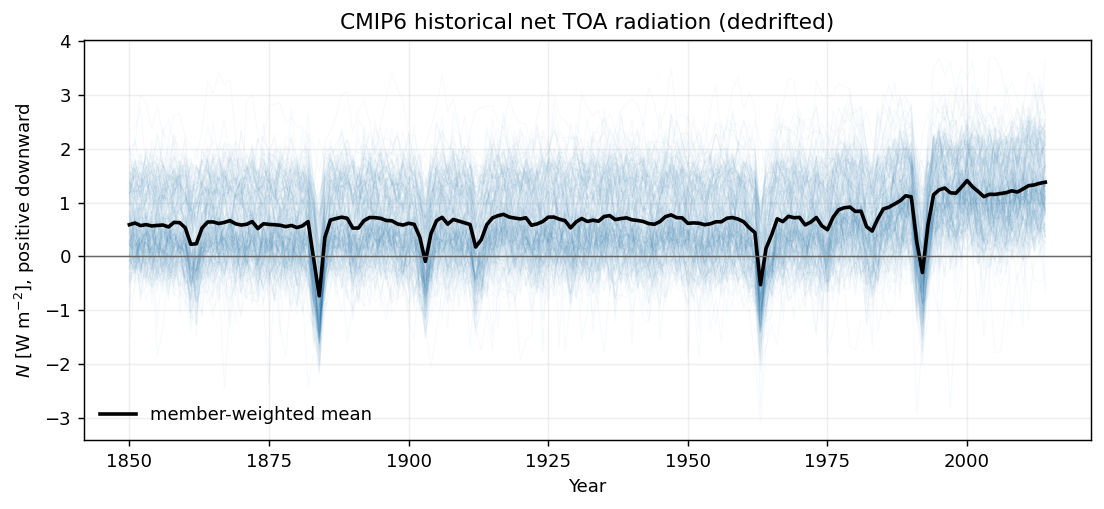

In [8]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=130)
ax.plot(
    net_toa_ds["year"],
    net_toa_ds["net_toa"].transpose("year", "member"),
    color="tab:blue",
    alpha=0.035,
    lw=0.6,
)
ax.plot(
    net_toa_ds["year"],
    net_toa_ds["net_toa"].mean("member"),
    color="black",
    lw=2,
    label="member-weighted mean",
)
ax.axhline(0, color="0.4", lw=0.8)
ax.set(
    title=f"CMIP6 historical net TOA radiation ({DATA_PRODUCT})",
    xlabel="Year",
    ylabel=r"$N$ [W m$^{-2}$], positive downward",
)
ax.grid(alpha=0.2)
ax.legend(frameon=False)
plt.show()

## Exploratory 1850–1900 spread

The member-weighted distribution strongly overweights models with large ensembles. Therefore the notebook also averages members within each `source_id` before calculating an equal-model spread. Both are shown; the equal-model summary is generally the more defensible inter-model comparison.

In [9]:
pi_period = slice(1850, 1900)
pi_member_mean = net_toa_ds["net_toa"].sel(year=pi_period).mean("year")

pi_members = pd.DataFrame(
    {
        "member": net_toa_ds["member"].values,
        "institution": net_toa_ds["institution"].values,
        "source_id": net_toa_ds["source_id"].values,
        "variant_label": net_toa_ds["variant_label"].values,
        "net_toa_1850_1900": pi_member_mean.values,
    }
)
pi_models = (
    pi_members.groupby("source_id", as_index=False)
    .agg(
        net_toa_1850_1900=("net_toa_1850_1900", "mean"),
        n_members=("member", "size"),
    )
)

def spread_summary(values):
    values = np.asarray(values, dtype=float)
    quantiles = np.quantile(values, [0.05, 0.17, 0.50, 0.83, 0.95])
    return pd.Series(
        {
            "n": len(values),
            "mean": values.mean(),
            "std (ddof=1)": values.std(ddof=1),
            "p05": quantiles[0],
            "p17": quantiles[1],
            "p50": quantiles[2],
            "p83": quantiles[3],
            "p95": quantiles[4],
        }
    )

pi_spread_summary = pd.DataFrame(
    {
        "ensemble members (member weighted)": spread_summary(
            pi_members["net_toa_1850_1900"]
        ),
        "models (equal source_id weight)": spread_summary(
            pi_models["net_toa_1850_1900"]
        ),
    }
).T
display(pi_spread_summary.round(3))
display(pi_models.sort_values("net_toa_1850_1900"))

,n,mean,std (ddof=1),p05,p17,p50,p83,p95
ensemble members (member weighted),241.0,0.552,0.599,-0.181,0.046,0.285,1.183,1.541
models (equal source_id weight),30.0,0.621,0.716,-0.275,0.039,0.354,1.297,1.840


,source_id,net_toa_1850_1900,n_members
17,GISS-E2-1-G-CC,-0.340529,1
3,BCC-ESM1,-0.327242,3
28,NorESM2-MM,-0.210314,3
1,ACCESS-ESM1-5,-0.152678,10
7,CESM2-WACCM-FV2,-0.046105,3
16,GISS-E2-1-G,0.045372,38
19,HadGEM3-GC31-LL,0.116182,4
6,CESM2-WACCM,0.121200,3
18,GISS-E2-1-H,0.164581,15
20,HadGEM3-GC31-MM,0.184630,4


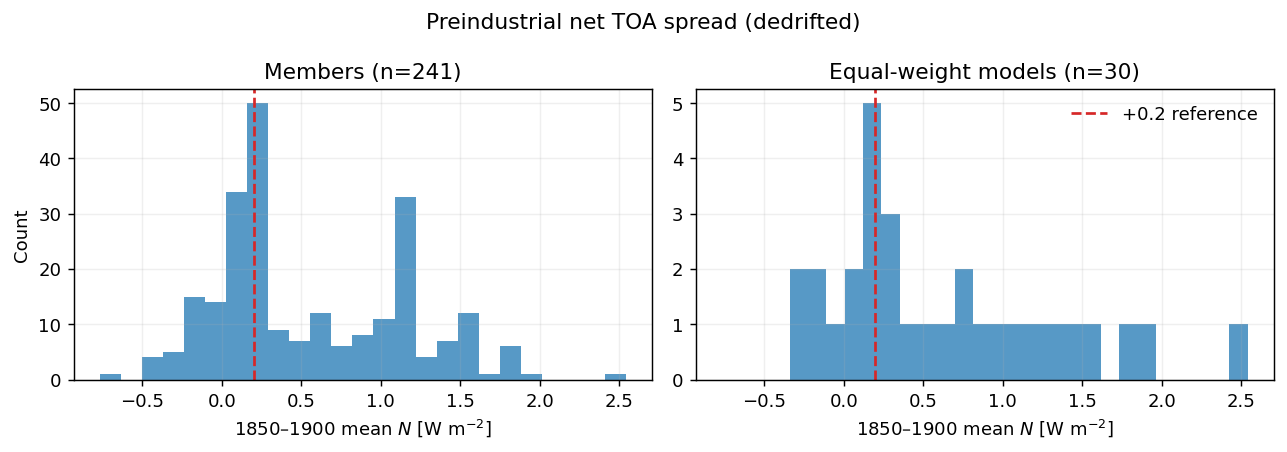

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=130, sharex=True)
for ax, values, title in [
    (
        axes[0],
        pi_members["net_toa_1850_1900"],
        f"Members (n={len(pi_members)})",
    ),
    (
        axes[1],
        pi_models["net_toa_1850_1900"],
        f"Equal-weight models (n={len(pi_models)})",
    ),
]:
    ax.hist(values, bins=25, color="tab:blue", alpha=0.75)
    ax.axvline(0.2, color="tab:red", ls="--", lw=1.5, label="+0.2 reference")
    ax.set(title=title, xlabel=r"1850–1900 mean $N$ [W m$^{-2}$]")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Count")
axes[1].legend(frameon=False)
fig.suptitle(f"Preindustrial net TOA spread ({DATA_PRODUCT})")
fig.tight_layout()
plt.show()

### Interpretation warning

The raw cross-model spread is **not automatically an uncertainty distribution for Earth's true preindustrial energy imbalance**. It includes model-specific TOA energy non-closure, control-state drift/spin-up, structural differences, and internal variability. It also depends on model weighting. Compare raw and dedrifted results, inspect control simulations if available, and decide explicitly which components represent uncertainty rather than model bias before using this spread as a prior. The red +0.2 W m$^{-2}$ line above is only a reference value, not evidence that the model distribution and the Sherwood et al. observationally informed assessment estimate the same quantity.

In [11]:
# Optional compact export. Provenance remains in the in-memory table above.
SAVE_NETCDF = False
OUTPUT_FILE = Path(f"cmip6_historical_net_toa_annual_{DATA_PRODUCT}.nc")

if SAVE_NETCDF:
    encoding = {name: {"zlib": True, "complevel": 4} for name in net_toa_ds.data_vars}
    net_toa_ds.to_netcdf(OUTPUT_FILE, encoding=encoding)
    print(f"Saved {OUTPUT_FILE.resolve()}")
else:
    print("SAVE_NETCDF is False; no data file was written.")

SAVE_NETCDF is False; no data file was written.


## Equal-model $\Delta N$ and variance decomposition

For member $r$ of model $m$, define

$$\Delta N_{mr} = \overline{N}_{mr,\,\mathrm{last\ 19\ years}} - \overline{N}_{mr,\,1850\text{–}1900}.$$

With `END_YEAR = 2014`, the final window is 1996–2014 inclusive. The overall estimate and intermodel spread give each `source_id` equal weight, regardless of ensemble size.

For internal variability, members are pooled only when they share the same CMIP6 initialization (`i`), physics (`p`), and forcing (`f`) indices and differ in realization (`r`). This avoids treating perturbed-physics or forcing-index differences as internal variability. The conventional pooled within-configuration variance is

$$s^2_{\mathrm{IV,pool}} = \frac{\sum_g (n_g-1)s_g^2}{\sum_g(n_g-1)},$$

where $g$ indexes model–`i/p/f` groups with at least two realizations. The observed intermodel variance is the sample variance of equal-weight model means. A second, approximate structural intermodel variance subtracts the estimated finite-ensemble sampling variance of those model means.

In [12]:
import re

N_RECENT_YEARS = 19
recent_end = int(net_toa_ds["year"].max())
recent_start = recent_end - N_RECENT_YEARS + 1
baseline_start, baseline_end = 1850, 1900

recent_mean = net_toa_ds["net_toa"].sel(
    year=slice(recent_start, recent_end)
).mean("year")
baseline_mean = net_toa_ds["net_toa"].sel(
    year=slice(baseline_start, baseline_end)
).mean("year")
delta_n_member_da = (recent_mean - baseline_mean).rename("delta_n")

delta_n_members = pd.DataFrame(
    {
        "member": net_toa_ds["member"].values,
        "institution": net_toa_ds["institution"].values,
        "source_id": net_toa_ds["source_id"].values,
        "variant_label": net_toa_ds["variant_label"].values,
        "delta_n": delta_n_member_da.values,
    }
)

variant_parts = delta_n_members["variant_label"].str.extract(
    r"^r(?P<realization>\d+)i(?P<initialization>\d+)"
    r"p(?P<physics>\d+)f(?P<forcing>\d+)$"
)
if variant_parts.isna().any(axis=None):
    bad_labels = delta_n_members.loc[variant_parts.isna().any(axis=1), "variant_label"]
    raise ValueError(f"Could not parse variant labels: {bad_labels.unique()}")
for column in variant_parts:
    delta_n_members[column] = variant_parts[column].astype(int)

# Equal weight is applied after averaging every available member of each source_id.
delta_n_models = (
    delta_n_members.groupby("source_id", as_index=False)
    .agg(
        delta_n=("delta_n", "mean"),
        n_members=("member", "size"),
        member_sd=("delta_n", "std"),
    )
    .sort_values("delta_n")
)

equal_model_delta_n_summary = spread_summary(delta_n_models["delta_n"]).to_frame(
    "equal-model delta N"
).T
print(
    f"Delta N = mean({recent_start}-{recent_end}) - "
    f"mean({baseline_start}-{baseline_end}); product={DATA_PRODUCT}"
)
display(equal_model_delta_n_summary.round(4))
display(delta_n_models.reset_index(drop=True))

Delta N = mean(1996-2014) - mean(1850-1900); product=dedrifted


,n,mean,std (ddof=1),p05,p17,p50,p83,p95
equal-model delta N,30.0,0.6876,0.1277,0.5435,0.5652,0.665,0.7936,0.9451


,source_id,delta_n,n_members,member_sd
0,NorESM2-MM,0.420472,3,0.072388
1,CNRM-CM6-1,0.542616,10,0.043912
2,CNRM-CM6-1-HR,0.544489,1,NaN
3,SAM0-UNICON,0.556874,1,NaN
4,CESM2,0.557046,11,0.051621
5,CNRM-ESM2-1,0.565809,10,0.064939
6,CESM2-FV2,0.589419,3,0.076479
7,MIROC6,0.597667,34,0.054132
8,BCC-ESM1,0.598944,3,0.062632
9,GISS-E2-1-H,0.616465,15,0.041228


In [13]:
config_columns = ["source_id", "initialization", "physics", "forcing"]
config_stats = (
    delta_n_members.groupby(config_columns, as_index=False)
    .agg(
        n=("delta_n", "size"),
        mean_delta_n=("delta_n", "mean"),
        variance=("delta_n", "var"),
    )
)
replicated_configs = config_stats.query("n >= 2").copy()
replicated_configs["df"] = replicated_configs["n"] - 1
replicated_configs["within_ss"] = (
    replicated_configs["df"] * replicated_configs["variance"]
)

within_df = int(replicated_configs["df"].sum())
pooled_internal_variance = replicated_configs["within_ss"].sum() / within_df

# A model-specific pooled estimate supports the equal-model sensitivity estimate.
internal_by_model = (
    replicated_configs.groupby("source_id", as_index=False)
    .agg(within_ss=("within_ss", "sum"), within_df=("df", "sum"))
)
internal_by_model["internal_variance"] = (
    internal_by_model["within_ss"] / internal_by_model["within_df"]
)
equal_model_internal_variance = internal_by_model["internal_variance"].mean()

observed_intermodel_variance = delta_n_models["delta_n"].var(ddof=1)

# Model means retain finite-ensemble internal variability. Use each model's
# estimate where possible and the global pooled value for singleton models.
model_variance_inputs = delta_n_models.merge(
    internal_by_model[["source_id", "internal_variance"]],
    on="source_id",
    how="left",
)
model_variance_inputs["internal_variance_filled"] = model_variance_inputs[
    "internal_variance"
].fillna(pooled_internal_variance)
model_variance_inputs["sampling_variance_of_mean"] = (
    model_variance_inputs["internal_variance_filled"]
    / model_variance_inputs["n_members"]
)
mean_sampling_variance = model_variance_inputs["sampling_variance_of_mean"].mean()
adjusted_intermodel_variance = max(
    0.0, observed_intermodel_variance - mean_sampling_variance
)

variance_components = pd.DataFrame(
    [
        {
            "quantity": "internal variability: conventional pooled within i/p/f",
            "variance": pooled_internal_variance,
            "notes": f"{within_df} within-group df",
        },
        {
            "quantity": "internal variability: equal-model mean of model variances",
            "variance": equal_model_internal_variance,
            "notes": f"{len(internal_by_model)} models with replicated i/p/f groups",
        },
        {
            "quantity": "intermodel: observed variance of equal-weight model means",
            "variance": observed_intermodel_variance,
            "notes": f"{len(delta_n_models)} source_id means",
        },
        {
            "quantity": "internal sampling variance remaining in model means",
            "variance": mean_sampling_variance,
            "notes": "mean estimated Var(model mean)",
        },
        {
            "quantity": "intermodel: adjusted structural variance",
            "variance": adjusted_intermodel_variance,
            "notes": "observed intermodel variance minus finite-ensemble sampling variance",
        },
    ]
).set_index("quantity")
variance_components["standard_deviation"] = np.sqrt(
    variance_components["variance"]
)
variance_components.attrs["variance_units"] = "(W m-2)^2"
variance_components.attrs["standard_deviation_units"] = "W m-2"
display(variance_components.round(5))
display(replicated_configs.sort_values(["source_id", "forcing"]))

,variance,notes,standard_deviation
quantity,,,
internal variability: conventional pooled within i/p/f,0.00329,204 within-group df,0.05736
internal variability: equal-model mean of model variances,0.00350,24 models with replicated i/p/f groups,0.05912
intermodel: observed variance of equal-weight model means,0.01631,30 source_id means,0.12771
internal sampling variance remaining in model means,0.00122,mean estimated Var(model mean),0.03498
intermodel: adjusted structural variance,0.01509,observed intermodel variance minus finite-ensemble sampling variance,0.12282


,source_id,initialization,physics,forcing,n,mean_delta_n,variance,df,within_ss
0,ACCESS-CM2,1,1,1,3,0.740156,0.001120,2,0.002240
1,ACCESS-ESM1-5,1,1,1,10,0.694685,0.004459,9,0.040130
2,AWI-CM-1-1-MR,1,1,1,5,0.724727,0.005152,4,0.020610
3,BCC-ESM1,1,1,1,3,0.598944,0.003923,2,0.007845
4,CESM2,1,1,1,11,0.557046,0.002665,10,0.026648
5,CESM2-FV2,1,1,1,3,0.589419,0.005849,2,0.011698
6,CESM2-WACCM,1,1,1,3,0.702865,0.003582,2,0.007163
7,CESM2-WACCM-FV2,1,1,1,3,0.652684,0.001645,2,0.003289
9,CNRM-CM6-1,1,1,2,10,0.542616,0.001928,9,0.017355
11,CNRM-ESM2-1,1,1,2,10,0.565809,0.004217,9,0.037953


The unadjusted intermodel variance is the directly observed spread requested above. The adjusted value is a method-of-moments estimate: it removes the average estimated internal-variability variance still present in finite ensemble means. This correction assumes members are independent and that within-ensemble variability represents the relevant sampling noise. Models with one member cannot estimate their own internal variance, so the conventional pooled variance is used for their correction.

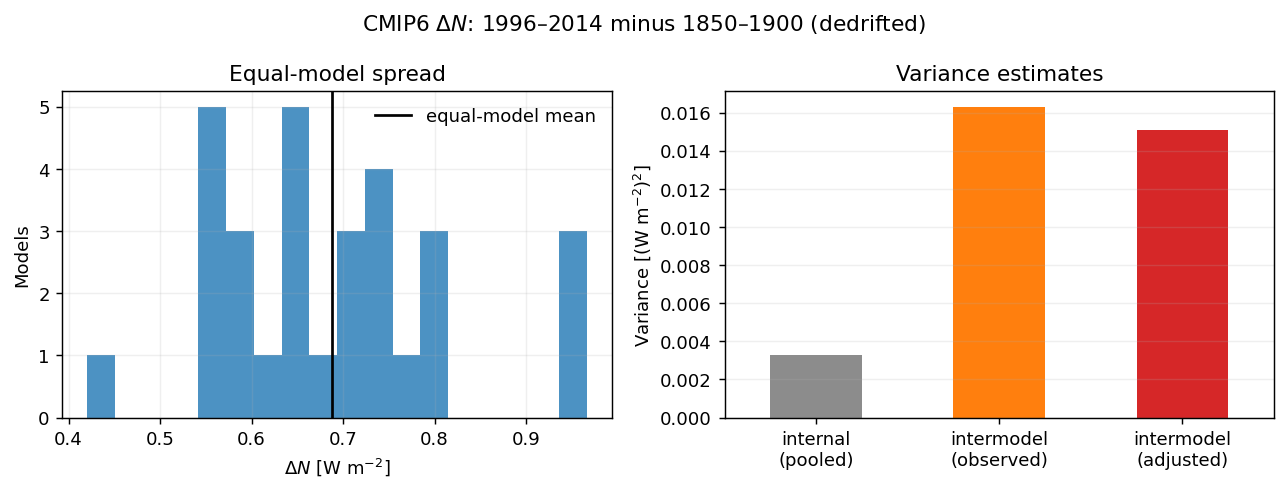

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), dpi=130)

axes[0].hist(delta_n_models["delta_n"], bins=18, color="tab:blue", alpha=0.8)
axes[0].axvline(
    delta_n_models["delta_n"].mean(),
    color="black",
    lw=1.5,
    label="equal-model mean",
)
axes[0].set(
    title="Equal-model spread",
    xlabel=r"$\Delta N$ [W m$^{-2}$]",
    ylabel="Models",
)
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.2)

component_plot = pd.Series(
    {
        "internal\n(pooled)": pooled_internal_variance,
        "intermodel\n(observed)": observed_intermodel_variance,
        "intermodel\n(adjusted)": adjusted_intermodel_variance,
    }
)
component_plot.plot.bar(ax=axes[1], color=["0.55", "tab:orange", "tab:red"])
axes[1].set(
    title="Variance estimates",
    ylabel=r"Variance [(W m$^{-2}$)$^2$]",
    xlabel="",
)
axes[1].tick_params(axis="x", rotation=0)
axes[1].grid(axis="y", alpha=0.2)

fig.suptitle(
    f"CMIP6 $\Delta N$: {recent_start}–{recent_end} minus "
    f"{baseline_start}–{baseline_end} ({DATA_PRODUCT})"
)
fig.tight_layout()
plt.show()

## Ballinger et al. (2026) UKESM1-1-LL historical1750 ensemble

Load the six `historical1750` ensemble members from the GloSAT/Ballinger et al. archive and calculate annual global-mean net TOA radiation,

$$N = rsdt - rsut - rlut.$$

These are monthly gridded NetCDF files on the native N96 atmosphere grid. The files reference external `areacella`, but that field is not present in this directory. Exact spherical cell-area weights are therefore calculated from the supplied latitude and longitude bounds. The 360-day calendar has 12 equal-length months per year.

The primary calculation follows the requested periods literally: mean(1850–1900) minus mean(1750–1850), with both endpoints included. This counts 1850 in both periods. A non-overlapping mean(1850–1900) minus mean(1750–1849) sensitivity is also reported.

In [32]:
BALLINGER_ROOT = Path(
    "/glade/derecho/scratch/vcooper/p2c2/historical/"
    "ballinger2026_ukesm1750/GloSAT_historical1750"
)
BALLINGER_VARIABLES = ("rsdt", "rsut", "rlut")
BALLINGER_LATE_PERIOD = (1850, 1900)
BALLINGER_EARLY_PERIOD = (1750, 1849)  # Literal request; overlaps in 1850.
BALLINGER_EARLY_NONOVERLAP = (1750, 1800)

if not BALLINGER_ROOT.is_dir():
    raise FileNotFoundError(BALLINGER_ROOT)

ballinger_member_dirs = sorted(path for path in BALLINGER_ROOT.iterdir() if path.is_dir())
if len(ballinger_member_dirs) != 6:
    raise ValueError(
        f"Expected 6 Ballinger ensemble members; found {len(ballinger_member_dirs)}"
    )
print("Members:", [path.name for path in ballinger_member_dirs])

Members: ['r1i1p1f2', 'r2i1p1f2', 'r3i1p1f2', 'r4i1p1f2', 'r5i1p1f2', 'r6i1p1f2']


In [33]:
def spherical_cell_area_weights(dataset):
    """Dimensionless spherical cell areas from one-dimensional bounds."""
    required = {"lat_bnds", "lon_bnds"}
    missing = required - set(dataset.variables)
    if missing:
        raise ValueError(f"Missing grid bounds: {sorted(missing)}")

    lat_lower = np.deg2rad(dataset["lat_bnds"].isel(bnds=0))
    lat_upper = np.deg2rad(dataset["lat_bnds"].isel(bnds=1))
    lat_factor = abs(np.sin(lat_upper) - np.sin(lat_lower))

    lon_lower = dataset["lon_bnds"].isel(bnds=0)
    lon_upper = dataset["lon_bnds"].isel(bnds=1)
    lon_width_degrees = abs(lon_upper - lon_lower)
    lon_factor = np.deg2rad(lon_width_degrees)

    weights = (lat_factor * lon_factor).rename("cell_area_weight")
    if not bool((weights > 0).all()):
        raise ValueError("Non-positive spherical cell-area weight")
    np.testing.assert_allclose(float(weights.sum()), 4 * np.pi, rtol=1e-10)
    return weights


def load_annual_global_mean(files, variable):
    """Area-average monthly files, then return complete annual means."""
    files = sorted(Path(path) for path in files)
    if not files:
        raise FileNotFoundError(f"No {variable} files")

    annual_segments = []
    for path in files:
        with xr.open_dataset(path, decode_times=True) as dataset:
            if variable not in dataset:
                raise KeyError(f"{variable} is absent from {path}")
            if dataset["time"].encoding.get("calendar") != "360_day":
                raise ValueError(f"Unexpected calendar in {path}")
            if dataset[variable].attrs.get("units") != "W m-2":
                raise ValueError(f"Unexpected units in {path}")

            weights = spherical_cell_area_weights(dataset)
            monthly_global = (
                dataset[variable]
                .weighted(weights)
                .mean(("lat", "lon"))
                .load()
            )
            months_per_year = monthly_global.groupby("time.year").count()
            if not bool((months_per_year == 12).all()):
                raise ValueError(f"Incomplete year in {path}")
            annual_segments.append(
                monthly_global.groupby("time.year").mean("time")
            )

    annual = xr.concat(annual_segments, dim="year").sortby("year")
    years = annual["year"].to_numpy().astype(int)
    if len(np.unique(years)) != len(years):
        raise ValueError(f"Duplicate years after combining {variable} segments")
    np.testing.assert_array_equal(years, np.arange(years.min(), years.max() + 1))
    annual.name = variable
    annual.attrs.update({"units": "W m-2", "spatial_mean": "global area weighted"})
    return annual


def load_ballinger_ensemble(root):
    member_datasets = []
    provenance_rows = []

    for member_dir in sorted(path for path in root.iterdir() if path.is_dir()):
        member = member_dir.name
        annual_fluxes = {}
        source_files = {}
        for variable in BALLINGER_VARIABLES:
            files = sorted((member_dir / variable).glob("*.nc"))
            if len(files) != 3:
                raise ValueError(
                    f"Expected 3 {variable} segments for {member}; found {len(files)}"
                )
            annual_fluxes[variable] = load_annual_global_mean(files, variable)
            source_files[variable] = " | ".join(str(path) for path in files)

        member_dataset = xr.Dataset(annual_fluxes)
        member_dataset["net_toa"] = (
            member_dataset["rsdt"]
            - member_dataset["rsut"]
            - member_dataset["rlut"]
        )
        member_dataset["net_toa"].attrs.update(
            {
                "long_name": "Net top-of-atmosphere downward radiative flux",
                "formula": "rsdt - rsut - rlut",
                "positive": "down",
                "units": "W m-2",
            }
        )
        member_datasets.append(member_dataset.expand_dims(member=[member]))
        provenance_rows.append({"member": member, **source_files})
        print(f"Loaded {member}")

    ensemble = xr.concat(member_datasets, dim="member", join="exact")
    ensemble.attrs.update(
        {
            "source": "Ballinger et al. (2026) GloSAT historical1750",
            "source_id": "UKESM1-1-LL",
            "source_directory": str(root),
        }
    )
    provenance = pd.DataFrame(provenance_rows).set_index("member")
    return ensemble, provenance

In [34]:
ballinger_ds, ballinger_provenance = load_ballinger_ensemble(BALLINGER_ROOT)

np.testing.assert_array_equal(ballinger_ds["year"], np.arange(1750, 2015))
assert ballinger_ds.sizes == {"member": 6, "year": 265}
assert np.isfinite(ballinger_ds.to_array()).all()
ballinger_identity_error = abs(
    ballinger_ds["net_toa"]
    - (ballinger_ds["rsdt"] - ballinger_ds["rsut"] - ballinger_ds["rlut"])
).max().item()
assert ballinger_identity_error < 1e-10

print(ballinger_ds)
print(f"Maximum formula identity error: {ballinger_identity_error:.3g} W m-2")
display(ballinger_provenance)

Loaded r1i1p1f2
Loaded r2i1p1f2
Loaded r3i1p1f2
Loaded r4i1p1f2
Loaded r5i1p1f2
Loaded r6i1p1f2
<xarray.Dataset> Size: 53kB
Dimensions:  (member: 6, year: 265)
Coordinates:
  * member   (member) object 48B 'r1i1p1f2' 'r2i1p1f2' ... 'r5i1p1f2' 'r6i1p1f2'
  * year     (year) int64 2kB 1750 1751 1752 1753 1754 ... 2011 2012 2013 2014
Data variables:
    rsdt     (member, year) float64 13kB 340.5 340.5 340.4 ... 340.4 340.4 340.5
    rsut     (member, year) float64 13kB 98.1 98.13 97.89 ... 97.8 97.79 97.17
    rlut     (member, year) float64 13kB 242.4 242.2 242.4 ... 241.6 241.4 241.8
    net_toa  (member, year) float64 13kB 0.02023 0.1616 0.1072 ... 1.258 1.441
Attributes:
    source:            Ballinger et al. (2026) GloSAT historical1750
    source_id:         UKESM1-1-LL
    source_directory:  /glade/derecho/scratch/vcooper/p2c2/historical/balling...
Maximum formula identity error: 0 W m-2


,rsdt,rsut,rlut
member,,,
r1i1p1f2,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r1i1p1f2/rsdt/rsdt_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r1i1p1f2/rsut/rsut_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r1i1p1f2/rlut/rlut_Amon...
r2i1p1f2,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r2i1p1f2/rsdt/rsdt_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r2i1p1f2/rsut/rsut_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r2i1p1f2/rlut/rlut_Amon...
r3i1p1f2,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r3i1p1f2/rsdt/rsdt_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r3i1p1f2/rsut/rsut_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r3i1p1f2/rlut/rlut_Amon...
r4i1p1f2,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r4i1p1f2/rsdt/rsdt_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r4i1p1f2/rsut/rsut_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r4i1p1f2/rlut/rlut_Amon...
r5i1p1f2,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r5i1p1f2/rsdt/rsdt_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r5i1p1f2/rsut/rsut_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r5i1p1f2/rlut/rlut_Amon...
r6i1p1f2,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r6i1p1f2/rsdt/rsdt_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r6i1p1f2/rsut/rsut_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r6i1p1f2/rlut/rlut_Amon...


,rsdt,rsut,rlut
member,,,
r1i1p1f2,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r1i1p1f2/rsdt/rsdt_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r1i1p1f2/rsut/rsut_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r1i1p1f2/rlut/rlut_Amon...
r2i1p1f2,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r2i1p1f2/rsdt/rsdt_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r2i1p1f2/rsut/rsut_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r2i1p1f2/rlut/rlut_Amon...
r3i1p1f2,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r3i1p1f2/rsdt/rsdt_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r3i1p1f2/rsut/rsut_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r3i1p1f2/rlut/rlut_Amon...
r4i1p1f2,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r4i1p1f2/rsdt/rsdt_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r4i1p1f2/rsut/rsut_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r4i1p1f2/rlut/rlut_Amon...
r5i1p1f2,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r5i1p1f2/rsdt/rsdt_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r5i1p1f2/rsut/rsut_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r5i1p1f2/rlut/rlut_Amon...
r6i1p1f2,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r6i1p1f2/rsdt/rsdt_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r6i1p1f2/rsut/rsut_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r6i1p1f2/rlut/rlut_Amon...


In [35]:
def annual_period_mean(data_array, period):
    start, end = period
    selected = data_array.sel(year=slice(start, end))
    expected_n_years = end - start + 1
    if selected.sizes["year"] != expected_n_years:
        raise ValueError(f"Incomplete period {start}-{end}")
    return selected.mean("year")


ballinger_late_mean = annual_period_mean(
    ballinger_ds["net_toa"], BALLINGER_LATE_PERIOD
)
ballinger_early_mean = annual_period_mean(
    ballinger_ds["net_toa"], BALLINGER_EARLY_PERIOD
)
ballinger_early_nonoverlap_mean = annual_period_mean(
    ballinger_ds["net_toa"], BALLINGER_EARLY_NONOVERLAP
)
ballinger_delta_eei = (ballinger_late_mean - ballinger_early_mean).rename(
    "delta_eei_literal"
)
ballinger_delta_eei_nonoverlap = (
    ballinger_late_mean - ballinger_early_nonoverlap_mean
).rename("delta_eei_nonoverlap")

ballinger_member_periods = pd.DataFrame(
    {
        "member": ballinger_ds["member"].values,
        "mean_N_1750_1850": ballinger_early_mean.values,
        "mean_N_1750_1849": ballinger_early_nonoverlap_mean.values,
        "mean_N_1850_1900": ballinger_late_mean.values,
        "delta_N_literal": ballinger_delta_eei.values,
        "delta_N_nonoverlap": ballinger_delta_eei_nonoverlap.values,
    }
)

def small_ensemble_summary(values):
    values = np.asarray(values, dtype=float)
    quantiles = np.quantile(values, [0.05, 0.17, 0.50, 0.83, 0.95])
    return pd.Series(
        {
            "n": len(values),
            "mean": values.mean(),
            "variance (ddof=1)": values.var(ddof=1),
            "std (ddof=1)": values.std(ddof=1),
            "min": values.min(),
            "p05": quantiles[0],
            "p17": quantiles[1],
            "p50": quantiles[2],
            "p83": quantiles[3],
            "p95": quantiles[4],
            "max": values.max(),
        }
    )

ballinger_delta_summary = pd.DataFrame(
    {
        "1850-1900 minus 1750-1850 (literal)": small_ensemble_summary(
            ballinger_delta_eei.values
        ),
        "1850-1900 minus 1750-1849 (non-overlap)": small_ensemble_summary(
            ballinger_delta_eei_nonoverlap.values
        ),
    }
).T
ballinger_delta_summary.attrs["units"] = "W m-2"

display(ballinger_member_periods.round(5))
display(ballinger_delta_summary.round(5))
print("With only six members, empirical tail percentiles are descriptive, not robust.")

,member,mean_N_1750_1850,mean_N_1750_1849,mean_N_1850_1900,delta_N_literal,delta_N_nonoverlap
0,r1i1p1f2,-0.01437,0.04452,0.09779,0.11216,0.05327
1,r2i1p1f2,0.02666,0.05859,0.06318,0.03652,0.00459
2,r3i1p1f2,0.03024,0.05979,0.10099,0.07076,0.04121
3,r4i1p1f2,0.00420,0.08271,0.07916,0.07496,-0.00355
4,r5i1p1f2,-0.00136,0.01691,0.12696,0.12832,0.11005
5,r6i1p1f2,0.00714,0.03530,0.07771,0.07057,0.04241


,n,mean,variance (ddof=1),std (ddof=1),min,p05,p17,p50,p83,p95,max
1850-1900 minus 1750-1850 (literal),6.0,0.08221,0.00109,0.03295,0.03652,0.04503,0.06546,0.07286,0.11458,0.12428,0.12832
1850-1900 minus 1750-1849 (non-overlap),6.0,0.04133,0.00165,0.04057,-0.00355,-0.00151,0.00337,0.04181,0.06178,0.09586,0.11005


With only six members, empirical tail percentiles are descriptive, not robust.


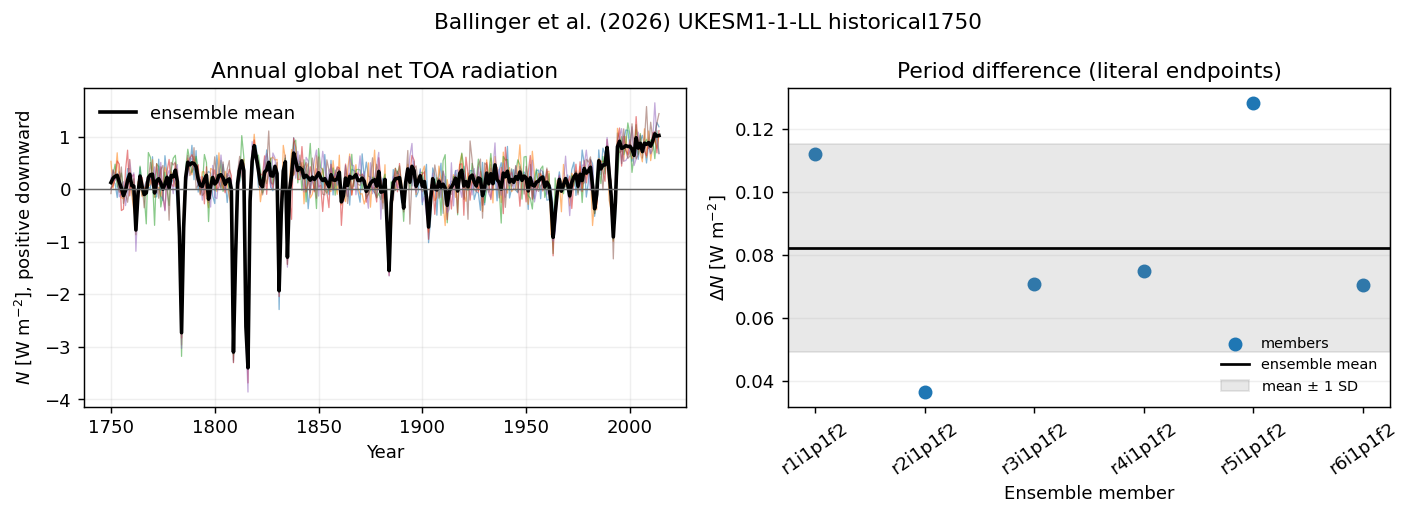

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=130)

for member in ballinger_ds["member"].values:
    axes[0].plot(
        ballinger_ds["year"],
        ballinger_ds["net_toa"].sel(member=member),
        lw=0.7,
        alpha=0.55,
    )
axes[0].plot(
    ballinger_ds["year"],
    ballinger_ds["net_toa"].mean("member"),
    color="black",
    lw=2,
    label="ensemble mean",
)
axes[0].axhline(0, color="0.4", lw=0.8)
axes[0].set(
    title="Annual global net TOA radiation",
    xlabel="Year",
    ylabel=r"$N$ [W m$^{-2}$], positive downward",
)
axes[0].grid(alpha=0.2)
axes[0].legend(frameon=False)

members_x = np.arange(ballinger_ds.sizes["member"])
axes[1].scatter(
    members_x,
    ballinger_delta_eei,
    s=45,
    color="tab:blue",
    label="members",
)
delta_mean = float(ballinger_delta_eei.mean())
delta_sd = float(ballinger_delta_eei.std(ddof=1))
axes[1].axhline(delta_mean, color="black", lw=1.5, label="ensemble mean")
axes[1].axhspan(
    delta_mean - delta_sd,
    delta_mean + delta_sd,
    color="0.5",
    alpha=0.18,
    label=r"mean $\pm$ 1 SD",
)
axes[1].set(
    title="Period difference (literal endpoints)",
    xlabel="Ensemble member",
    ylabel=r"$\Delta N$ [W m$^{-2}$]",
    xticks=members_x,
    xticklabels=ballinger_ds["member"].values,
)
axes[1].tick_params(axis="x", rotation=35)
axes[1].grid(axis="y", alpha=0.2)
axes[1].legend(frameon=False, fontsize=8)

fig.suptitle("Ballinger et al. (2026) UKESM1-1-LL historical1750")
fig.tight_layout()
plt.show()

In [42]:
print((ballinger_ds["net_toa"].sel(year=slice(2006,2014)).mean(dim='year') - ballinger_ds["net_toa"].sel(year=slice(1850,1900)).mean(dim='year')).mean())

print((ballinger_ds["net_toa"].sel(year=slice(2006,2014)).mean(dim='year') - ballinger_ds["net_toa"].sel(year=slice(1750,1800)).mean(dim='year')).mean())

<xarray.DataArray 'net_toa' ()> Size: 8B
array(0.81712301)
<xarray.DataArray 'net_toa' ()> Size: 8B
array(0.85845203)
